In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

import sys
from pathlib import Path

sys.path.append(str(Path("../scripts").resolve()))
from functions import *

palette = plt.cm.viridis
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

In [28]:
data = pd.read_csv('../results/data.csv', index_col='Cluster')
df =  pd.read_csv('../results/results.csv', index_col='Cluster')

new_masses, new_comp_masses = np.load('../results/new_masses.npy'), np.load('../results/new_comp_masses.npy')

In [3]:
m1 = data['mass'].values
m2 = data['comp_mass'].values
q=m2/m1

log_m1 = np.log10(m1)
log_m2 = np.log10(m2)

min_mass = min(log_m1.min(), log_m2[log_m2>0].min())
max_mass = log_m1.max()

mass_bins, P_prim, P_comp, P_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)

dP_prim_arr, dP_comp_arr, dP_BS_arr = [], [], []
for i in range(0,len(new_masses)):
    new_comp_masses[i][q ==0] = 0
    
    log_m1 = np.log10(new_masses[i])
    log_m2 = np.log10(new_comp_masses[i])
    mb, dP_prim, dP_comp, dP_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)
    dP_prim = np.interp(mass_bins, mb, dP_prim, left=np.nan, right=np.nan)
    dP_comp = np.interp(mass_bins, mb, dP_comp, left=np.nan, right=np.nan)
    dP_BS = np.interp(mass_bins, mb, dP_BS, left=np.nan, right=np.nan)

    dP_prim_arr.append(dP_prim)
    dP_comp_arr.append(dP_comp)
    dP_BS_arr.append(dP_BS)



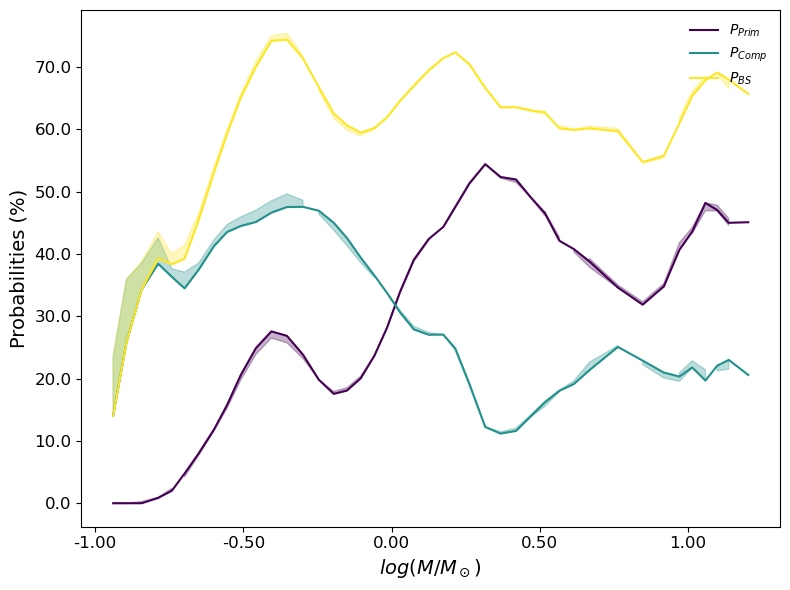

In [4]:
nominal_values = [P_prim, P_comp, P_BS]
standard_devs = [dP_prim_arr, dP_comp_arr, dP_BS_arr]

labels = [r'$P_{Prim}$', r'$P_{Comp}$', r'$P_{BS}$']
cmap = plt.cm.viridis
cores = cmap(np.linspace(0, 1, 3))


fig, axs = plt.subplots(figsize=(8,6))

for i in range(0, len(nominal_values)):
    axs.plot(mass_bins,  nominal_values[i]*100,label = labels[i], color = cores[i])    
    minimos = np.array([min(col) for col in zip(*standard_devs[i])])*100
    maximos = np.array([max(col) for col in zip(*standard_devs[i])])*100
    axs.fill_between(mass_bins, nominal_values[i]*100, maximos, alpha=0.3, color=cores[i], where = maximos>=nominal_values[i]*100)
    axs.fill_between(mass_bins, minimos, nominal_values[i]*100, alpha=0.3, color=cores[i], where = minimos<=nominal_values[i]*100)
    
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
axs.set_ylabel(r'Probabilities (%)', fontdict=font)
axs.set_xlabel(r'$log(M/M_\odot)$', fontdict=font)
plt.legend(loc='upper right',frameon=False)
plt.tight_layout()
#plt.savefig('Figures/dist_fb_por_massa.png', dpi=300)
plt.show()



In [7]:
data = pd.read_csv('../results/data.csv', index_col='Cluster')
new_masses, new_comp_masses = np.load('../results/new_masses.npy'), np.load('../results/new_comp_masses.npy')

m1 = data['mass'].values
m2 = data['comp_mass'].values
q = m2/m1

log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

dq_arr = []
for i in range(0,len(new_masses)):
    
    log_m1_bin = np.log10(new_masses[i][q>0])
    q_ = new_comp_masses[i][q>0]/new_masses[i][q>0]

    min_mass = log_m1_bin.min()
    max_mass = log_m1_bin.max()
    
    mb, dq = loop_mass_ratio(log_m1_bin, q_, min_mass, max_mass, dm=0.05)
    dq = np.interp(mass_bins, mb, dq, left=np.nan, right=np.nan)

    dq_arr.append(dq)

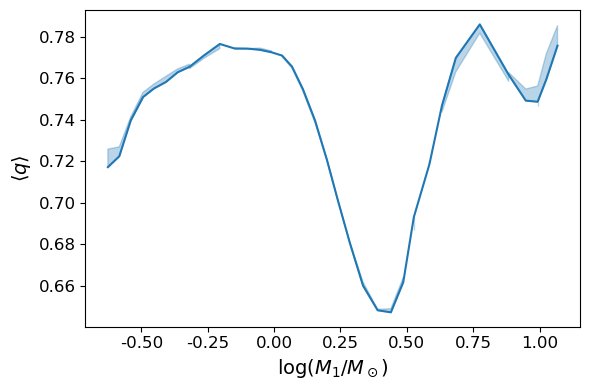

In [8]:
minimos = [min(col) for col in zip(*dq_arr)]
maximos = [max(col) for col in zip(*dq_arr)]

fig, axs = plt.subplots(figsize=(6,4))


axs.fill_between(mass_bins, qs, maximos, alpha=0.3, color='tab:blue', where = maximos>=qs)
axs.fill_between(mass_bins, minimos, qs, alpha=0.3, color='tab:blue', where = minimos<=qs)
axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
#plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
#plt.savefig('dist_q_por_massa_034.png', dpi=300)
plt.show() 

In [9]:
(10**mass_bins[np.argmin(qs)]).round(2)

np.float64(2.75)

In [10]:
#data2 = pd.read_csv('Data/data.csv')

#m1 = data2['mass'].values
#m2 = data2['comp_mass'].values
#q = m2/m1

#log_m1_bin = np.log10(m1[q>0])

#min_mass = log_m1_bin.min()
#max_mass = log_m1_bin.max()

#mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

#dq_arr = []
#minimos = [min(col) for col in zip(*dq_arr)]
#maximos = [max(col) for col in zip(*dq_arr)]

#fig, axs = plt.subplots(figsize=(6,4))


#axs.fill_between(mass_bins, qs, maximos, alpha=0.3, color='tab:blue', where = maximos>=qs)
#axs.fill_between(mass_bins, minimos, qs, alpha=0.3, color='tab:blue', where = minimos<=qs)
#axs.plot(mass_bins, qs)

#axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
#axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
#axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
#axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
#axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
#plt.title('All binaries (q>0)')
#plt.tight_layout()
#plt.xlim(-0.6, 1.1)
#plt.show() 

In [17]:
clusters = ['Alessi_3', 'Alessi_13', 'ASCC_58',
           'Colinder_140', 'Colinder_359', 'IC_4665',
           'Ruprecht_161', 'Stock_2', 'Ruprecht_91',
           'NGC_2632', 'Stock_1', 'Collinder_394',
           'NGC_5822', 'NGC_2447', 'NGC_2548',
           'NGC_3532', 'NGC_2287', 'NGC_2422']

In [20]:
rotation = []

In [21]:
for c in clusters:
    if c in data.index.unique():
        rotation.append(c)

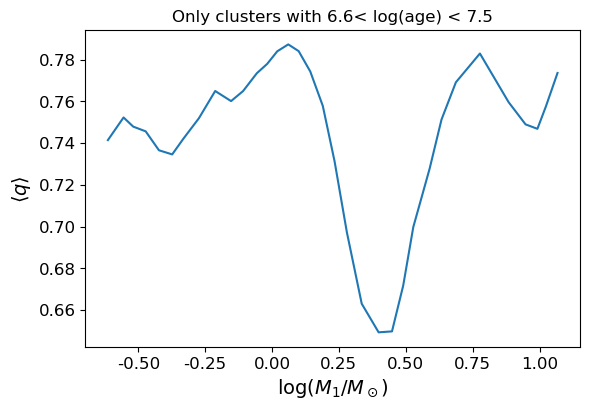

In [103]:
aux = data.loc[df[df['age']<=7.5].index
].copy()
m1 = aux['mass'].values
m2 = aux['comp_mass'].values
q = m2/m1

log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)


fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
#plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
#plt.savefig('dist_q_por_massa_034.png', dpi=300)
plt.title('Only clusters with 6.6< log(age) < 7.5')
plt.savefig('jovens.png', dpi=300)
plt.show() 

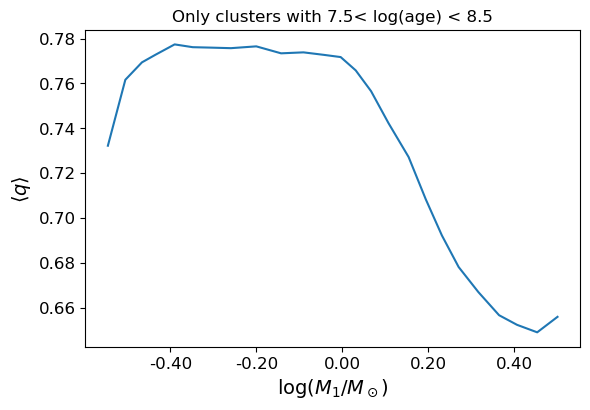

In [154]:
aux = data.loc[df[(df['age']>8) & (df['age']<=9)].index].copy()
m1 = aux['mass'].values
m2 = aux['comp_mass'].values
q = m2/m1

log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)


fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
#plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
#plt.savefig('dist_q_por_massa_034.png', dpi=300)
plt.title('Only clusters with 7.5< log(age) < 8.5')
plt.savefig('intermed.png', dpi=300)
plt.show() 

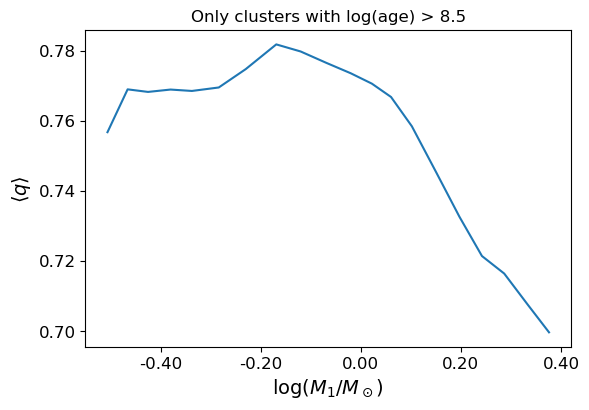

In [114]:
aux = data.loc[df[(df['age']>=8.5)].index].copy()
m1 = aux['mass'].values
m2 = aux['comp_mass'].values
q = m2/m1

log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)


fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
#plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
#plt.savefig('dist_q_por_massa_034.png', dpi=300)
plt.title('Only clusters with log(age) > 8.5')
plt.savefig('older.png', dpi=300)
plt.show() 

In [101]:
def plot_cmd(df):
    fig, ax = plt.subplots(figsize=(6,4))

    ax.scatter(df['BPRP'], df['Gmag'], c='lightgray', s=10)

    dip = df[(df['mass'] >= 2) &
             (df['mass'] <= 3.5) &
             (df['q'] > 0)]

    ax.scatter(dip['BPRP'], dip['Gmag'], c='tomato', s=10, label=r'$2< M_1 < 3 \,M_\odot$')

    ax.invert_yaxis()

    ax.set_xlabel('BP - RP')
    ax.set_ylabel('Gmag')
    plt.title(f'{df.index.unique()[0]}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{cluster}_cmd.png', dpi=300)
    plt.show()

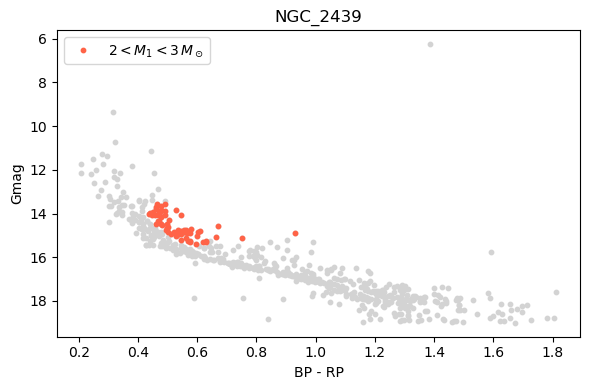

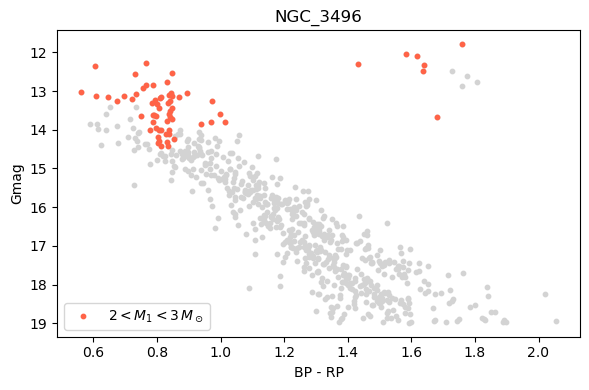

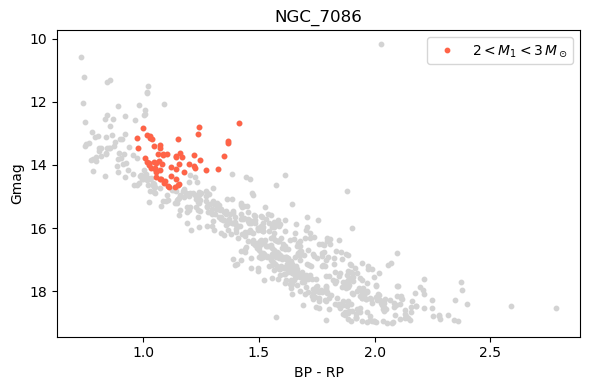

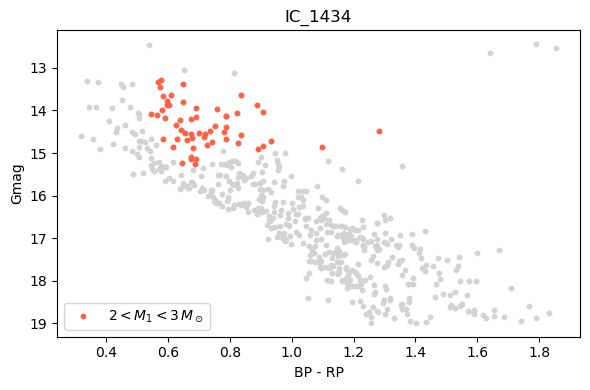

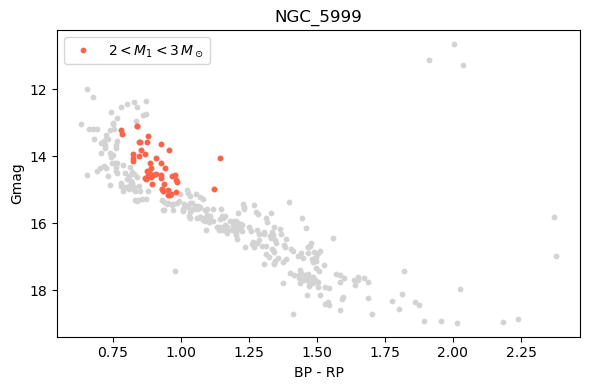

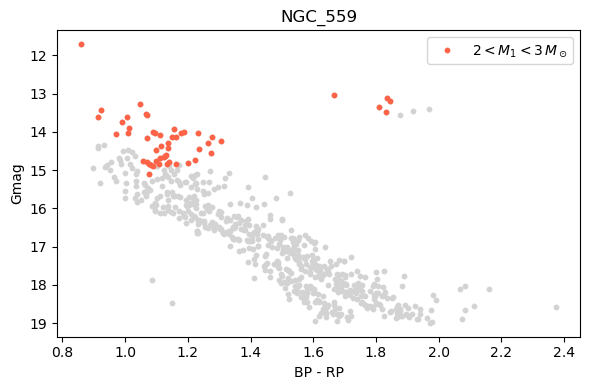

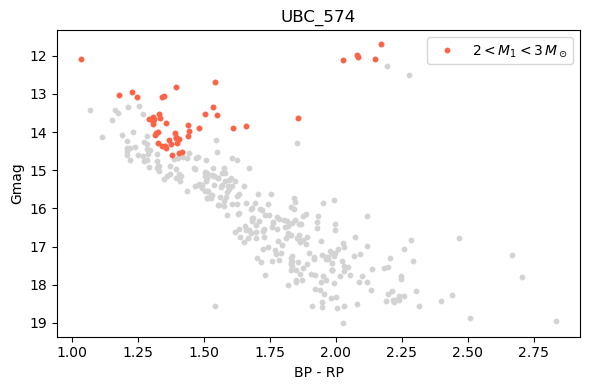

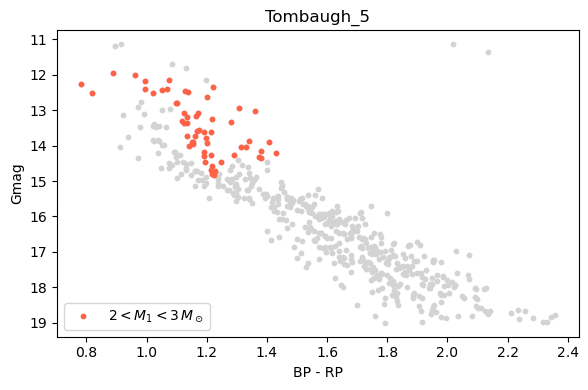

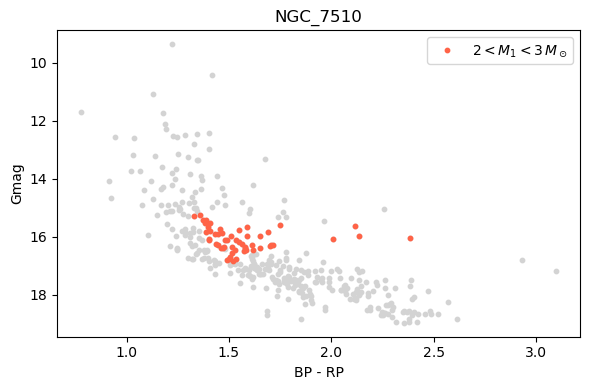

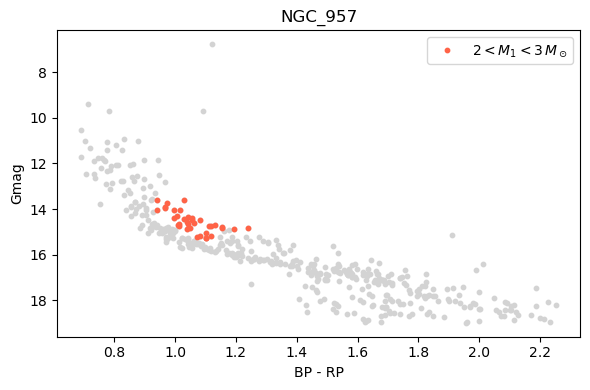

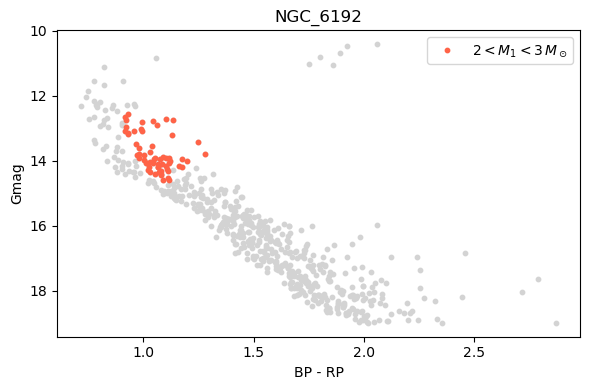

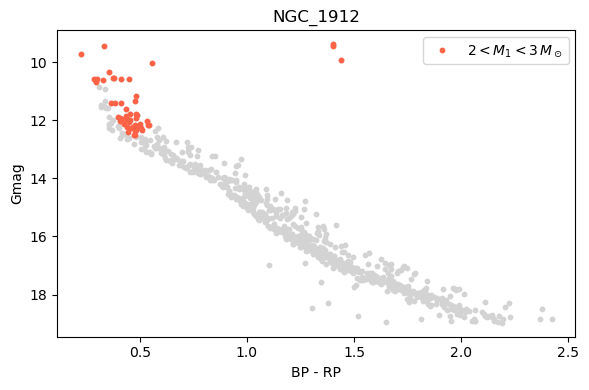

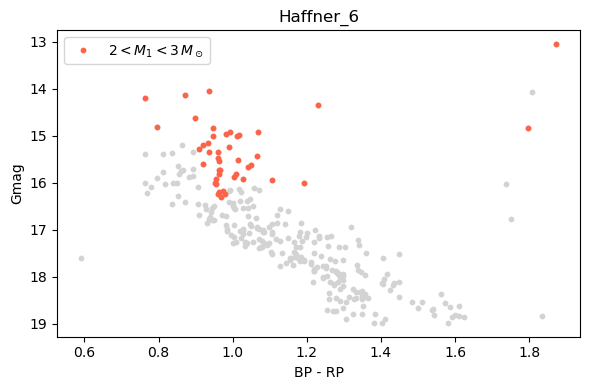

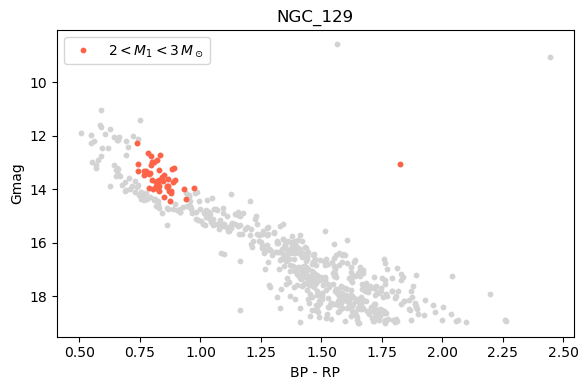

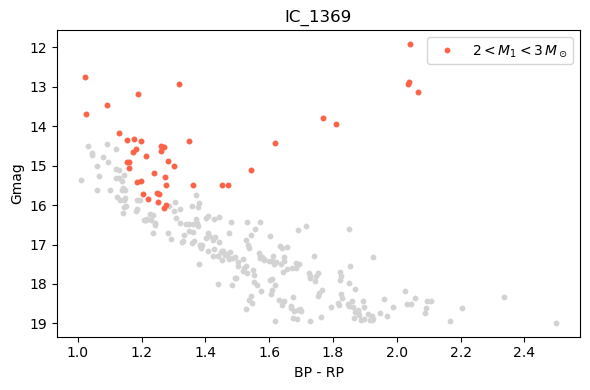

In [121]:

aux = data[(data.mass>2) & (data.mass<3)].copy()
for cluster in aux.index.value_counts().head(15).index:
    plot_cmd(data.loc[cluster])

In [149]:
aux = data[(data.mass>2) & (data.mass<3)].copy()
clusters = aux.index.value_counts()[aux.index.value_counts()>10].index
aux = data.loc[~data.index.isin(clusters)]

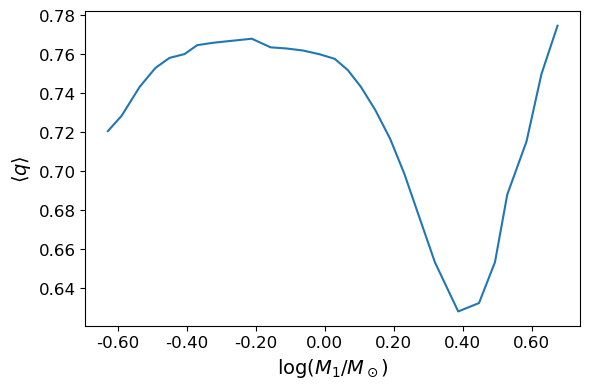

In [150]:

m1 = aux['mass'].values
m2 = aux['comp_mass'].values
q = m2/m1

log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)


fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
#plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
#plt.savefig('dist_q_por_massa_034.png', dpi=300)

plt.show() 

In [118]:
df.loc[df.index.isin(clusters)]['age'].describe()

count    5.000000
mean     8.399200
std      0.637196
min      7.265000
25%      8.615000
50%      8.625000
75%      8.734000
max      8.757000
Name: age, dtype: float64

In [136]:
aux.index.value_counts()[aux.index.value_counts()>10]

Cluster
NGC_2439    96
NGC_3496    91
NGC_7086    86
IC_1434     81
NGC_5999    79
            ..
UBC_347     11
UBC_382     11
UBC_527     11
UPK_17      11
UPK_621     11
Name: count, Length: 346, dtype: int64

In [158]:
df = df.round(2)
benchmark_flag = (df['dist']<1.5) & (df['Av']<0.5)
    
tabela_formatada = pd.DataFrame({
        'f_bin': df.apply(lambda x: format_erro(x['bin_frac_corr'], x['er_bin_frac']), axis=1),
        'f_bin_0.5': df.apply(lambda x: format_erro(x['bin_frac_05_corr'], x['er_bin_frac_05']), axis=1),
        'r_h': df.apply(lambda x: format_erro(x['rh'], x['e_rh']), axis=1),
        't_relax (Myr)': df.apply(lambda x: format_erro(x['t_relax'], x['e_t_relax']), axis=1),
        'τ': df.apply(lambda x: format_erro(x['tau'], x['e_tau']), axis=1),
        'benchmark_flag': benchmark_flag,
    })
    
    # Exporta para LaTeX
tabela_latex = tabela_formatada.to_latex(index=True, escape=False)
with open("tabela_resultados.tex", "w", encoding="utf-8") as f:
    f.write(tabela_latex)